In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/mennathabett/multispectral-satellite-imagery-labels/labels/38_68.png
/kaggle/input/datasets/mennathabett/multispectral-satellite-imagery-labels/labels/121_142.png
/kaggle/input/datasets/mennathabett/multispectral-satellite-imagery-labels/labels/173.png
/kaggle/input/datasets/mennathabett/multispectral-satellite-imagery-labels/labels/248.png
/kaggle/input/datasets/mennathabett/multispectral-satellite-imagery-labels/labels/94.png
/kaggle/input/datasets/mennathabett/multispectral-satellite-imagery-labels/labels/40_277.png
/kaggle/input/datasets/mennathabett/multispectral-satellite-imagery-labels/labels/18_42.png
/kaggle/input/datasets/mennathabett/multispectral-satellite-imagery-labels/labels/236.png
/kaggle/input/datasets/mennathabett/multispectral-satellite-imagery-labels/labels/85_117.png
/kaggle/input/datasets/mennathabett/multispectral-satellite-imagery-labels/labels/48.png
/kaggle/input/datasets/mennathabett/multispectral-satellite-imagery-labels/labels/23_251

# Step 1: EDA

## Step 1.1 — Setup & Sanity Check on One File

In [2]:
import rasterio
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import os

IMAGES_DIR = "/kaggle/input/datasets/mennathabett/multispectral-satellite-imagery-images/images"
LABELS_DIR = "/kaggle/input/datasets/mennathabett/multispectral-satellite-imagery-labels/labels"

# Pick one sample to inspect first
sample_img_path = os.path.join(IMAGES_DIR, "5.tif")

with rasterio.open(sample_img_path) as src:
    img = src.read()  # shape: (bands, H, W)
    print("Shape:", img.shape)
    print("Dtype:", img.dtype)
    print("Min per band:", img.min(axis=(1, 2)))
    print("Max per band:", img.max(axis=(1, 2)))
    print("Mean per band:", img.mean(axis=(1, 2)))

Shape: (12, 128, 128)
Dtype: int16
Min per band: [-37  -1  43  44 334 152  75  64 754 739  10   0]
Max per band: [ 808 2364 2977 3400 3540 4897 3876  192 1203 1197   60    0]
Mean per band: [ 234.57672119  303.57824707  464.32879639  547.159729   1580.40081787
 1613.9944458  1059.38250732   64.45117188  959.87329102  946.01519775
   19.03686523    0.        ]


/usr/local/lib/python3.12/dist-packages/rasterio/__init__.py:367: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset = DatasetReader(path, driver=driver, sharing=sharing, thread_safe=thread_safe, **kwargs)


## Step 1.2 — Dataset-Wide Structure Check

In [3]:
image_files = sorted([f for f in os.listdir(IMAGES_DIR) if f.endswith(".tif")])
print("Number of image samples:", len(image_files))

shapes = set()
dtypes = set()
for f in image_files:
    with rasterio.open(os.path.join(IMAGES_DIR, f)) as src:
        shapes.add(src.read().shape)
        dtypes.add(src.dtypes[0])

print("Unique shapes found:", shapes)
print("Unique dtypes found:", dtypes)

Number of image samples: 306
Unique shapes found: {(12, 128, 128)}
Unique dtypes found: {'int16'}


## Step 1.3 — Matching Images to Labels

In [4]:
def get_clean_label_files(labels_dir):
    """keeping only label files matching pattern: <number>.png (no underscore)"""
    all_files = os.listdir(labels_dir)
    clean = [f for f in all_files if f.endswith(".png") and "_" not in f]
    return sorted(clean, key=lambda x: int(x.split(".")[0]))

label_files = get_clean_label_files(LABELS_DIR)
print("Number of clean label files:", len(label_files))
print(label_files[:10])

Number of clean label files: 306
['0.png', '1.png', '2.png', '3.png', '4.png', '5.png', '6.png', '7.png', '8.png', '9.png']


In [5]:
image_ids = sorted([int(f.split(".")[0]) for f in image_files])
label_ids = sorted([int(f.split(".")[0]) for f in label_files])

print("Image IDs range:", min(image_ids), "-", max(image_ids), "| count:", len(image_ids))
print("Label IDs range:", min(label_ids), "-", max(label_ids), "| count:", len(label_ids))
print("IDs in images but not labels:", set(image_ids) - set(label_ids))
print("IDs in labels but not images:", set(label_ids) - set(image_ids))

Image IDs range: 0 - 305 | count: 306
Label IDs range: 0 - 305 | count: 306
IDs in images but not labels: set()
IDs in labels but not images: set()


## Step 1.4 — Visualize All 12 Bands for One Sample

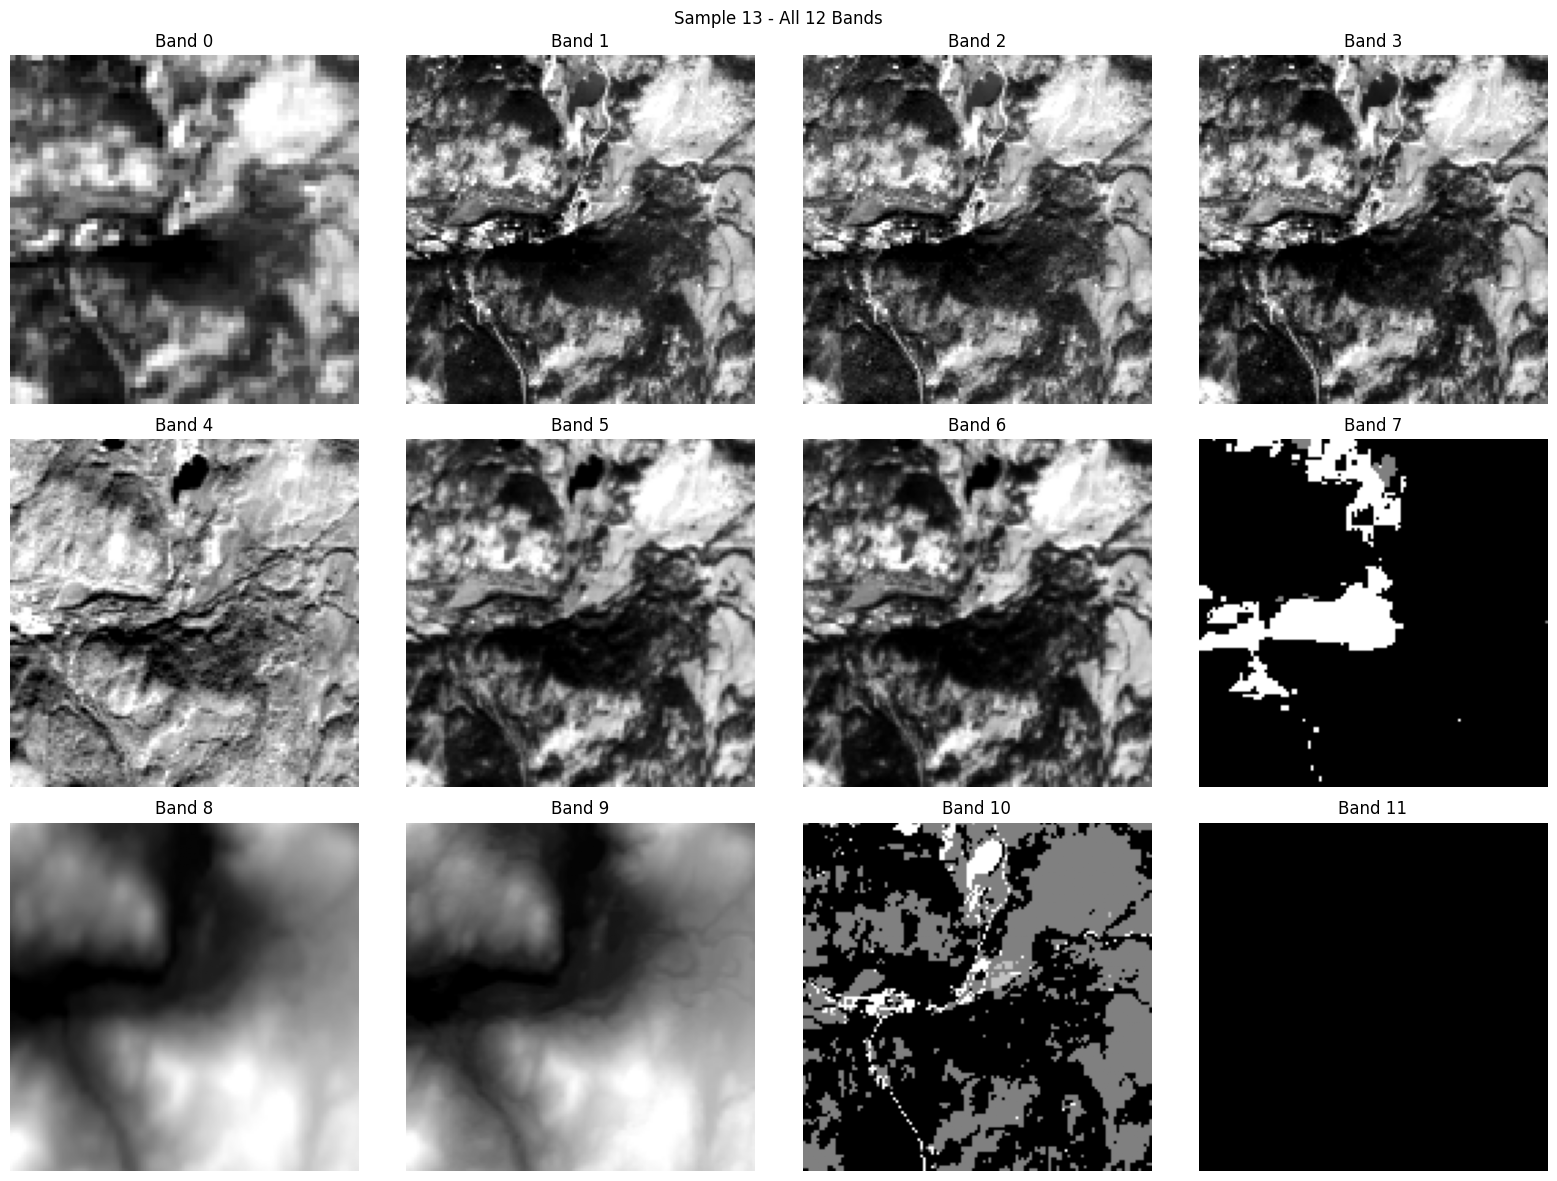

In [6]:
def load_tif(path):
    with rasterio.open(path) as src:
        return src.read()  # (12, H, W)

def stretch(band, low=2, high=98):
    """Percentile stretch for visualization"""
    lo, hi = np.percentile(band, [low, high])
    band = np.clip(band, lo, hi)
    if hi - lo == 0:
        return np.zeros_like(band, dtype=np.float32)
    return (band - lo) / (hi - lo)

sample_id = 13  # a sample with visible water
img = load_tif(os.path.join(IMAGES_DIR, f"{sample_id}.tif"))

fig, axes = plt.subplots(3, 4, figsize=(16, 12))
for i, ax in enumerate(axes.flat):
    band_stretched = stretch(img[i])
    ax.imshow(band_stretched, cmap='gray')
    ax.set_title(f"Band {i}")
    ax.axis('off')
plt.suptitle(f"Sample {sample_id} - All 12 Bands")
plt.tight_layout()
plt.savefig("band_visualization.png", dpi=100)
plt.show()

## Step 1.5 — RGB Composite + Mask Overlay

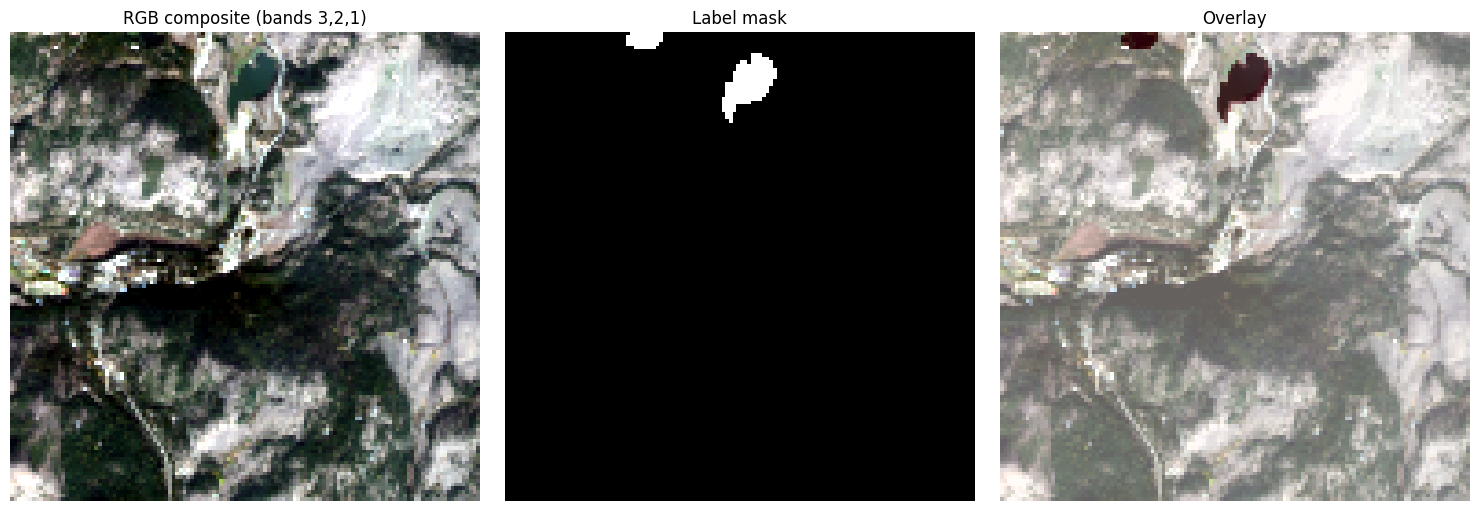

In [7]:
def load_mask(sample_id):
    mask = np.array(Image.open(os.path.join(LABELS_DIR, f"{sample_id}.png")))
    return mask

# RGB index - Sentinel-2 L2A order is often:
# RGB = indices 3,2,1 (Red,Green,Blue)
rgb = np.stack([stretch(img[3]), stretch(img[2]), stretch(img[1])], axis=-1)
mask = load_mask(sample_id)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(rgb)
axes[0].set_title("RGB composite (bands 3,2,1)")
axes[1].imshow(mask, cmap='gray')
axes[1].set_title("Label mask")
axes[2].imshow(rgb)
axes[2].imshow(mask, cmap='Reds', alpha=0.4)
axes[2].set_title("Overlay")
for ax in axes: ax.axis('off')
plt.tight_layout()
plt.show()

## Step 1.6 — Label Class Distribution (full dataset)

Unique mask values check (sample): [0 1]
Mean water % per image: 25.97528594771242
Images with 0% water: 45 / 306
Images with >20% water: 143


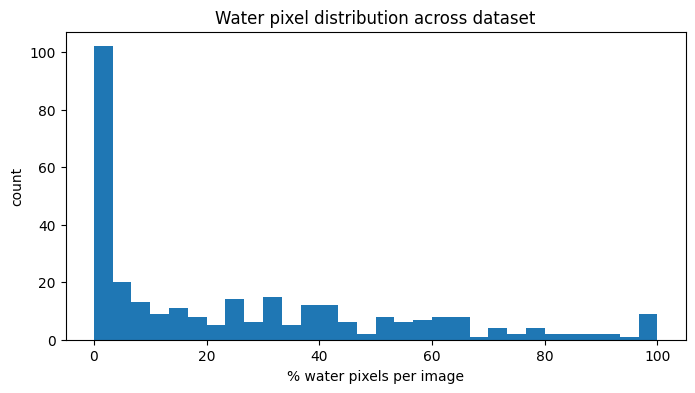

In [8]:
water_ratios = []
for f in label_files:
    m = np.array(Image.open(os.path.join(LABELS_DIR, f)))
    m = (m > 0).astype(np.uint8)  # ensure binary
    water_ratios.append(m.mean())

water_ratios = np.array(water_ratios)
print("Unique mask values check (sample):", np.unique(np.array(Image.open(os.path.join(LABELS_DIR, label_files[0])))))
print("Mean water % per image:", water_ratios.mean() * 100)
print("Images with 0% water:", (water_ratios == 0).sum(), "/", len(water_ratios))
print("Images with >20% water:", (water_ratios > 0.2).sum())

plt.figure(figsize=(8,4))
plt.hist(water_ratios * 100, bins=30)
plt.xlabel("% water pixels per image")
plt.ylabel("count")
plt.title("Water pixel distribution across dataset")
plt.show()

## Step 1.7 — Quick check: is band 11 zero everywhere?

In [9]:
band_all_zero = []
for f in image_files:
    with rasterio.open(os.path.join(IMAGES_DIR, f)) as src:
        img = src.read()
        band_all_zero.append((img == 0).all(axis=(1,2)))

band_all_zero = np.array(band_all_zero)  # (306, 12)
print("Fraction of images where each band is ALL zero:")
for i in range(12):
    print(f"Band {i}: {band_all_zero[:,i].mean()*100:.1f}%")

Fraction of images where each band is ALL zero:
Band 0: 0.0%
Band 1: 0.0%
Band 2: 0.0%
Band 3: 0.0%
Band 4: 0.0%
Band 5: 0.0%
Band 6: 0.0%
Band 7: 0.0%
Band 8: 0.0%
Band 9: 0.0%
Band 10: 0.0%
Band 11: 18.6%


# Step 2 — Preprocessing Pipeline

In [10]:
import torch
from torch.utils.data import Dataset, DataLoader

## Step 2.1: Compute per-band mean/std across the training set

In [11]:
def compute_band_stats(image_files, images_dir):
    all_bands = []  # will hold (306, 12) mean and std per image, then aggregate
    sums = np.zeros(12)
    sq_sums = np.zeros(12)
    pixel_count = 0

    for f in image_files:
        with rasterio.open(os.path.join(images_dir, f)) as src:
            img = src.read().astype(np.float64)  # (12,128,128)
        sums += img.sum(axis=(1,2))
        sq_sums += (img ** 2).sum(axis=(1,2))
        pixel_count += img.shape[1] * img.shape[2]

    mean = sums / pixel_count
    std = np.sqrt(sq_sums / pixel_count - mean ** 2)
    return mean, std

band_mean, band_std = compute_band_stats(image_files, IMAGES_DIR)
print("Per-band mean:", band_mean)
print("Per-band std:", band_std)

# saving for using at inference time
np.save("band_mean.npy", band_mean)
np.save("band_std.npy", band_std)

/usr/local/lib/python3.12/dist-packages/rasterio/__init__.py:367: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset = DatasetReader(path, driver=driver, sharing=sharing, thread_safe=thread_safe, **kwargs)


Per-band mean: [ 396.46767291  494.62102873  822.31978453  973.67496126 2090.11099642
 1964.05056902 1351.27395331  102.73963041  141.80390641  300.74136253
   35.10253308    9.75332642]
Per-band std: [ 270.06659307  325.97919685  418.12163021  586.70297516 1055.9846072
 1191.42226561  961.76258759   48.80401527 1364.98112115  496.03880723
   20.18452457   27.75830662]


## Step 2.2 — Train/Val Split (stratified by water presence)

In [12]:
from sklearn.model_selection import train_test_split

ids = np.array([int(f.split('.')[0]) for f in label_files])
has_water = (water_ratios > 0).astype(int) 

train_ids, val_ids = train_test_split(
    ids, test_size=0.2, random_state=42, stratify=has_water
)
print("Train:", len(train_ids), "Val:", len(val_ids))
print("Train water-present ratio:", has_water[train_ids].mean())
print("Val water-present ratio:", has_water[val_ids].mean())

Train: 244 Val: 62
Train water-present ratio: 0.8524590163934426
Val water-present ratio: 0.8548387096774194


## Step 2.3 — PyTorch Dataset Class

In [13]:
class WaterSegDataset(Dataset):
    def __init__(self, ids, images_dir, labels_dir, band_mean, band_std):
        self.ids = ids
        self.images_dir = images_dir
        self.labels_dir = labels_dir
        self.band_mean = band_mean.reshape(12, 1, 1)
        self.band_std = band_std.reshape(12, 1, 1)

    def __len__(self):
        return len(self.ids)

    def __getitem__(self, idx):
        sample_id = self.ids[idx]

        with rasterio.open(os.path.join(self.images_dir, f"{sample_id}.tif")) as src:
            img = src.read().astype(np.float32)  # (12, 128, 128)

        mask = np.array(Image.open(os.path.join(self.labels_dir, f"{sample_id}.png")))
        mask = (mask > 0).astype(np.float32)  # ensure binary (0/1)

        # Per-band normalization
        img = (img - self.band_mean) / (self.band_std + 1e-8)

        img_tensor = torch.from_numpy(img).float()          # (12,128,128)
        mask_tensor = torch.from_numpy(mask).float().unsqueeze(0)  # (1,128,128)

        assert img_tensor.shape == (12, 128, 128), f"Bad shape: {img_tensor.shape}"

        return img_tensor, mask_tensor


# Recompute stats on train split only
band_mean_train, band_std_train = compute_band_stats(
    [f"{i}.tif" for i in train_ids], IMAGES_DIR
)

train_ds = WaterSegDataset(train_ids, IMAGES_DIR, LABELS_DIR, band_mean_train, band_std_train)
val_ds = WaterSegDataset(val_ids, IMAGES_DIR, LABELS_DIR, band_mean_train, band_std_train)

train_loader = DataLoader(train_ds, batch_size=16, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=16, shuffle=False)

# Sanity check
x, y = next(iter(train_loader))
print("Batch image shape:", x.shape)   
print("Batch mask shape:", y.shape)  
print("Image dtype/range:", x.dtype, x.min().item(), x.max().item())
print("Mask unique values:", torch.unique(y))

/usr/local/lib/python3.12/dist-packages/rasterio/__init__.py:367: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset = DatasetReader(path, driver=driver, sharing=sharing, thread_safe=thread_safe, **kwargs)


Batch image shape: torch.Size([16, 12, 128, 128])
Batch mask shape: torch.Size([16, 1, 128, 128])
Image dtype/range: torch.float32 -3.412074327468872 15.434885025024414
Mask unique values: tensor([0., 1.])


# Step 3 — U-Net Implementation

## Step 3.1 — Model Architecture

In [14]:
import torch
import torch.nn as nn

class DoubleConv(nn.Module):
    """(Conv -> BN -> ReLU) x 2"""
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.block(x)


class Down(nn.Module):
    """Maxpool -> DoubleConv"""
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.block = nn.Sequential(
            nn.MaxPool2d(2),
            DoubleConv(in_ch, out_ch)
        )

    def forward(self, x):
        return self.block(x)


class Up(nn.Module):
    """Upsample -> concat skip -> DoubleConv"""
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.up = nn.ConvTranspose2d(in_ch, in_ch // 2, kernel_size=2, stride=2)
        self.conv = DoubleConv(in_ch, out_ch)  # in_ch because concat doubles channels

    def forward(self, x, skip):
        x = self.up(x)
        # Handle any off-by-one size mismatch from odd input dims
        diffY = skip.size(2) - x.size(2)
        diffX = skip.size(3) - x.size(3)
        x = nn.functional.pad(x, [diffX // 2, diffX - diffX // 2,
                                   diffY // 2, diffY - diffY // 2])
        x = torch.cat([skip, x], dim=1)
        return self.conv(x)


class UNet(nn.Module):
    def __init__(self, in_channels=12, out_channels=1, base_ch=64):
        super().__init__()
        self.inc = DoubleConv(in_channels, base_ch)          # 128 -> 128
        self.down1 = Down(base_ch, base_ch * 2)               # 128 -> 64
        self.down2 = Down(base_ch * 2, base_ch * 4)            # 64 -> 32
        self.down3 = Down(base_ch * 4, base_ch * 8)            # 32 -> 16
        self.down4 = Down(base_ch * 8, base_ch * 16)           # 16 -> 8  (bottleneck)

        self.up1 = Up(base_ch * 16, base_ch * 8)
        self.up2 = Up(base_ch * 8, base_ch * 4)
        self.up3 = Up(base_ch * 4, base_ch * 2)
        self.up4 = Up(base_ch * 2, base_ch)

        self.outc = nn.Conv2d(base_ch, out_channels, kernel_size=1)

        self._init_weights()

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv2d) or isinstance(m, nn.ConvTranspose2d):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
                if m.bias is not None:
                    nn.init.zeros_(m.bias)
            elif isinstance(m, nn.BatchNorm2d):
                nn.init.ones_(m.weight)
                nn.init.zeros_(m.bias)

    def forward(self, x):
        x1 = self.inc(x)      # (B, 64, 128,128)
        x2 = self.down1(x1)   # (B, 128, 64,64)
        x3 = self.down2(x2)   # (B, 256, 32,32)
        x4 = self.down3(x3)   # (B, 512, 16,16)
        x5 = self.down4(x4)   # (B, 1024, 8,8)  bottleneck

        x = self.up1(x5, x4)  # -> (B, 512, 16,16)
        x = self.up2(x, x3)   # -> (B, 256, 32,32)
        x = self.up3(x, x2)   # -> (B, 128, 64,64)
        x = self.up4(x, x1)   # -> (B, 64, 128,128)

        logits = self.outc(x) # (B, 1, 128,128) - raw logits, sigmoid applied in loss/eval
        return logits

## Step 3.2 — Sanity Check the Model

In [15]:
model = UNet(in_channels=12, out_channels=1, base_ch=64)
x = torch.randn(4, 12, 128, 128)
out = model(x)
print("Output shape:", out.shape)  # expect (4, 1, 128, 128)

n_params = sum(p.numel() for p in model.parameters())
print(f"Total parameters: {n_params:,}")

Output shape: torch.Size([4, 1, 128, 128])
Total parameters: 31,048,705


# Step 4: Training Loop + Loss + Evaluation Metrics

## Step 4.1 — Loss Function (BCE + Dice)

In [16]:
import torch.nn.functional as F

class BCEDiceLoss(nn.Module):
    def __init__(self, bce_weight=0.5, smooth=1e-6):
        super().__init__()
        self.bce_weight = bce_weight
        self.smooth = smooth
        self.bce = nn.BCEWithLogitsLoss()

    def forward(self, logits, targets):
        bce_loss = self.bce(logits, targets)

        probs = torch.sigmoid(logits)
        probs_flat = probs.view(probs.size(0), -1)
        targets_flat = targets.view(targets.size(0), -1)

        intersection = (probs_flat * targets_flat).sum(dim=1)
        dice_score = (2. * intersection + self.smooth) / (
            probs_flat.sum(dim=1) + targets_flat.sum(dim=1) + self.smooth
        )
        dice_loss = 1 - dice_score.mean()

        return self.bce_weight * bce_loss + (1 - self.bce_weight) * dice_loss

## Step 4.2 — Evaluation Metrics (IoU, Precision, Recall, F1)

In [17]:
def compute_metrics(logits, targets, threshold=0.5, smooth=1e-6):
    probs = torch.sigmoid(logits)
    preds = (probs > threshold).float()

    preds_flat = preds.view(-1)
    targets_flat = targets.view(-1)

    tp = (preds_flat * targets_flat).sum().item()
    fp = (preds_flat * (1 - targets_flat)).sum().item()
    fn = ((1 - preds_flat) * targets_flat).sum().item()

    iou = (tp + smooth) / (tp + fp + fn + smooth)
    precision = (tp + smooth) / (tp + fp + smooth)
    recall = (tp + smooth) / (tp + fn + smooth)
    f1 = (2 * precision * recall) / (precision + recall + smooth)

    return {"iou": iou, "precision": precision, "recall": recall, "f1": f1}

## Step 4.3 — Training Loop

In [18]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

model = UNet(in_channels=12, out_channels=1, base_ch=64).to(device)
criterion = BCEDiceLoss(bce_weight=0.5)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)

NUM_EPOCHS = 100
EARLY_STOP_PATIENCE = 15  # stop if val IoU doesn't improve for this many epochs

best_val_iou = 0.0
epochs_no_improve = 0
history = {"train_loss": [], "val_loss": [], "val_iou": []}

for epoch in range(NUM_EPOCHS):
    # Train
    model.train()
    train_loss = 0.0
    for imgs, masks in train_loader:
        imgs, masks = imgs.to(device), masks.to(device)

        optimizer.zero_grad()
        logits = model(imgs)
        loss = criterion(logits, masks)
        loss.backward()
        optimizer.step()

        train_loss += loss.item() * imgs.size(0)

    train_loss /= len(train_ds)

    # Validate
    model.eval()
    val_loss = 0.0
    metric_accum = {"iou": 0.0, "precision": 0.0, "recall": 0.0, "f1": 0.0}

    with torch.no_grad():
        for imgs, masks in val_loader:
            imgs, masks = imgs.to(device), masks.to(device)
            logits = model(imgs)
            loss = criterion(logits, masks)
            val_loss += loss.item() * imgs.size(0)

            batch_metrics = compute_metrics(logits, masks)
            for k in metric_accum:
                metric_accum[k] += batch_metrics[k] * imgs.size(0)

    val_loss /= len(val_ds)
    for k in metric_accum:
        metric_accum[k] /= len(val_ds)

    scheduler.step(val_loss)

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["val_iou"].append(metric_accum["iou"])

    print(f"Epoch {epoch+1}/{NUM_EPOCHS} | "
          f"Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | "
          f"Val IoU: {metric_accum['iou']:.4f} | Val F1: {metric_accum['f1']:.4f} | "
          f"Val Precision: {metric_accum['precision']:.4f} | Val Recall: {metric_accum['recall']:.4f}")

    if metric_accum["iou"] > best_val_iou:
        best_val_iou = metric_accum["iou"]
        epochs_no_improve = 0
        torch.save(model.state_dict(), "best_unet_water_seg.pth")
    else:
        epochs_no_improve += 1
        if epochs_no_improve >= EARLY_STOP_PATIENCE:
            print(f"\nEarly stopping triggered at epoch {epoch+1} "
                  f"(no improvement in val IoU for {EARLY_STOP_PATIENCE} epochs).")
            break

print(f"\nTraining complete. Best Validation IoU: {best_val_iou:.4f}")

Using device: cuda


/usr/local/lib/python3.12/dist-packages/rasterio/__init__.py:367: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset = DatasetReader(path, driver=driver, sharing=sharing, thread_safe=thread_safe, **kwargs)


Epoch 1/100 | Train Loss: 0.6325 | Val Loss: 43.3360 | Val IoU: 0.2727 | Val F1: 0.4224 | Val Precision: 0.2747 | Val Recall: 0.9760
Epoch 2/100 | Train Loss: 0.4639 | Val Loss: 0.4855 | Val IoU: 0.6298 | Val F1: 0.7720 | Val Precision: 0.9271 | Val Recall: 0.6656
Epoch 3/100 | Train Loss: 0.4355 | Val Loss: 0.3807 | Val IoU: 0.7166 | Val F1: 0.8347 | Val Precision: 0.8993 | Val Recall: 0.7817
Epoch 4/100 | Train Loss: 0.4000 | Val Loss: 0.4027 | Val IoU: 0.6884 | Val F1: 0.8148 | Val Precision: 0.8222 | Val Recall: 0.8110
Epoch 5/100 | Train Loss: 0.3970 | Val Loss: 0.3723 | Val IoU: 0.7210 | Val F1: 0.8377 | Val Precision: 0.8710 | Val Recall: 0.8096
Epoch 6/100 | Train Loss: 0.3869 | Val Loss: 0.3745 | Val IoU: 0.7124 | Val F1: 0.8317 | Val Precision: 0.8886 | Val Recall: 0.7839
Epoch 7/100 | Train Loss: 0.3722 | Val Loss: 0.3572 | Val IoU: 0.7214 | Val F1: 0.8378 | Val Precision: 0.8920 | Val Recall: 0.7923
Epoch 8/100 | Train Loss: 0.3695 | Val Loss: 0.3829 | Val IoU: 0.6882 | Val

## Step 4.4 — Final Reported Metrics

In [19]:
model.load_state_dict(torch.load("best_unet_water_seg.pth"))
model.eval()

final_metrics = {"iou": 0.0, "precision": 0.0, "recall": 0.0, "f1": 0.0}
with torch.no_grad():
    for imgs, masks in val_loader:
        imgs, masks = imgs.to(device), masks.to(device)
        logits = model(imgs)
        batch_metrics = compute_metrics(logits, masks)
        for k in final_metrics:
            final_metrics[k] += batch_metrics[k] * imgs.size(0)

for k in final_metrics:
    final_metrics[k] /= len(val_ds)

print("=== Final Validation Metrics (Best Checkpoint) ===")
for k, v in final_metrics.items():
    print(f"{k.upper()}: {v:.4f}")

=== Final Validation Metrics (Best Checkpoint) ===
IOU: 0.8197
PRECISION: 0.9177
RECALL: 0.8856
F1: 0.9008


## Step 4.5 — Loss/IoU Curves

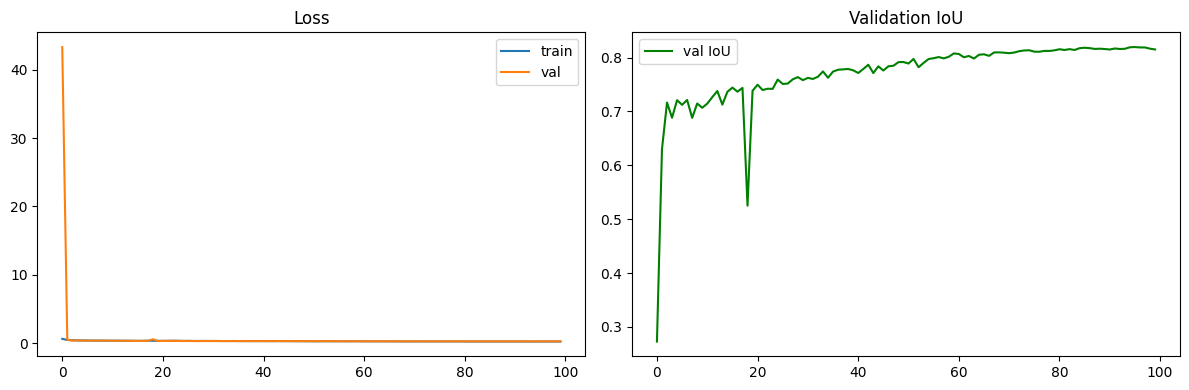

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(12,4))
axes[0].plot(history["train_loss"], label="train")
axes[0].plot(history["val_loss"], label="val")
axes[0].set_title("Loss"); axes[0].legend()
axes[1].plot(history["val_iou"], label="val IoU", color="green")
axes[1].set_title("Validation IoU"); axes[1].legend()
plt.tight_layout()
plt.savefig("training_curves.png")
plt.show()

## Step 4.6 — Prediction Visualizations

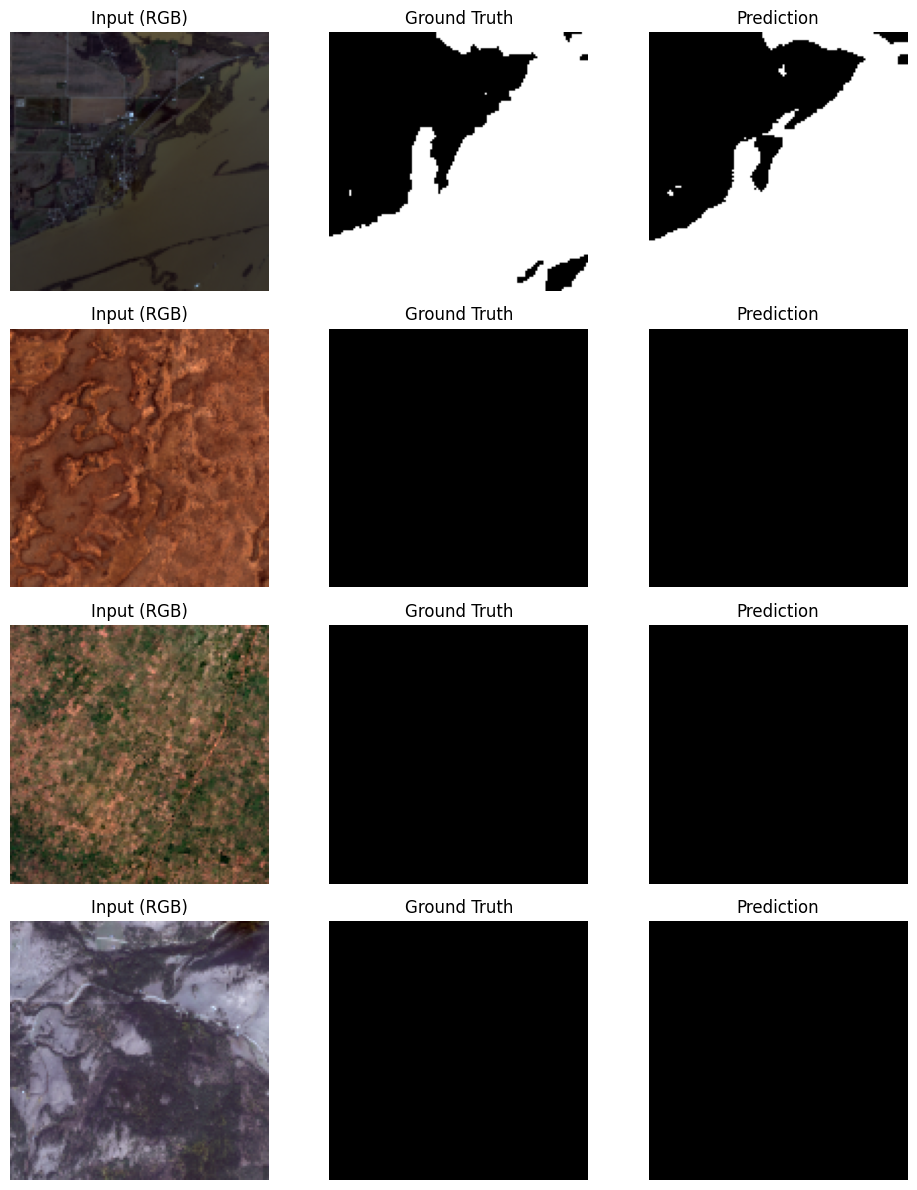

In [21]:
model.eval()
imgs, masks = next(iter(val_loader))
imgs, masks = imgs.to(device), masks.to(device)
with torch.no_grad():
    preds = torch.sigmoid(model(imgs)) > 0.5

fig, axes = plt.subplots(4, 3, figsize=(10, 12))
for i in range(4):
    rgb = imgs[i, [3,2,1]].cpu().permute(1,2,0).numpy()
    rgb = (rgb - rgb.min()) / (rgb.max() - rgb.min() + 1e-8)
    axes[i,0].imshow(rgb); axes[i,0].set_title("Input (RGB)"); axes[i,0].axis('off')
    axes[i,1].imshow(masks[i,0].cpu(), cmap='gray'); axes[i,1].set_title("Ground Truth"); axes[i,1].axis('off')
    axes[i,2].imshow(preds[i,0].cpu(), cmap='gray'); axes[i,2].set_title("Prediction"); axes[i,2].axis('off')
plt.tight_layout()
plt.savefig("prediction_samples.png", dpi=100)
plt.show()